# Data provisioning

#### Previous notebook: [Data collection](01_data_collection.ipynb)

## Split labels into separate columns
In the original disaster response dataset all labels per message are stored as a single string in the *categories* column, separated by semicolons. In this step, I split the labels into different columns, one per label. This is done to ensure the data is stored in a suitable format for converting each label values into numeric data type:

In [148]:
import pandas as pd

df_raw = pd.read_csv("../data/raw/disaster_dataset.csv")
cats_expanded = df_raw["categories"].str.split(";", expand=True)
row = cats_expanded.iloc[0]
category_colnames = row.apply(lambda x: x.split("-")[0])
cats_expanded.columns = category_colnames
cats_expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26144 entries, 0 to 26143
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   related                 26144 non-null  object
 1   request                 26144 non-null  object
 2   offer                   26144 non-null  object
 3   aid_related             26144 non-null  object
 4   medical_help            26144 non-null  object
 5   medical_products        26144 non-null  object
 6   search_and_rescue       26144 non-null  object
 7   security                26144 non-null  object
 8   military                26144 non-null  object
 9   child_alone             26144 non-null  object
 10  water                   26144 non-null  object
 11  food                    26144 non-null  object
 12  shelter                 26144 non-null  object
 13  clothing                26144 non-null  object
 14  money                   26144 non-null  object
 15  mi

In [149]:
cats_expanded.head()

,related,request,offer,aid_related,medical_help,medical_products,search_and_rescue,security,military,child_alone,...,aid_centers,other_infrastructure,weather_related,floods,storm,fire,earthquake,cold,other_weather,direct_report
0,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,child_alone-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
1,related-1,request-0,offer-0,aid_related-1,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,child_alone-0,...,aid_centers-0,other_infrastructure-0,weather_related-1,floods-0,storm-1,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
2,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,child_alone-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
3,related-1,request-1,offer-0,aid_related-1,medical_help-0,medical_products-1,search_and_rescue-0,security-0,military-0,child_alone-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
4,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,child_alone-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0


As we can see from the output above, the categories column is now separated into 36 label-based columns. Each column stores the name of the label and a number that represents whether the label applies to the message (1) or not (0). This ensures all labels were properly separated as their current count equals the original dataset documentation.

## Convert columns to numeric values
In this step, I go through all *label - number* values, remove the text, keep only the numeric value and cast it into an integer. Finally, I check the labels' data types, to ensure they are correctly stored and suitable to be used as target variables:

In [150]:
for col in category_colnames:
    cats_expanded[col] = cats_expanded[col].str.split("-").str[-1].astype(int)

df_raw = df_raw.drop(columns=["categories"])
df_raw = pd.concat([df_raw, cats_expanded], axis=1)
df_raw.to_csv("../data/raw/dd_raw_sep_labels.csv", index=False)
cats_expanded.dtypes

0
related                   int64
request                   int64
offer                     int64
aid_related               int64
medical_help              int64
medical_products          int64
search_and_rescue         int64
security                  int64
military                  int64
child_alone               int64
water                     int64
food                      int64
shelter                   int64
clothing                  int64
money                     int64
missing_people            int64
refugees                  int64
death                     int64
other_aid                 int64
infrastructure_related    int64
transport                 int64
buildings                 int64
electricity               int64
tools                     int64
hospitals                 int64
shops                     int64
aid_centers               int64
other_infrastructure      int64
weather_related           int64
floods                    int64
storm                     int64
fire  

## Check all unique values per column
After converting all column values to integers, I will go through all category columns, and store all unique values per label to verify whether the columns contain only binary values (1 and 0):

In [151]:
binary_check = {}

for col in cats_expanded.columns:
    vals = sorted(cats_expanded[col].unique().tolist())
    binary_check[col] = vals

binary_check

{'related': [0, 1, 2],
 'request': [0, 1],
 'offer': [0, 1],
 'aid_related': [0, 1],
 'medical_help': [0, 1],
 'medical_products': [0, 1],
 'search_and_rescue': [0, 1],
 'security': [0, 1],
 'military': [0, 1],
 'child_alone': [0],
 'water': [0, 1],
 'food': [0, 1],
 'shelter': [0, 1],
 'clothing': [0, 1],
 'money': [0, 1],
 'missing_people': [0, 1],
 'refugees': [0, 1],
 'death': [0, 1],
 'other_aid': [0, 1],
 'infrastructure_related': [0, 1],
 'transport': [0, 1],
 'buildings': [0, 1],
 'electricity': [0, 1],
 'tools': [0, 1],
 'hospitals': [0, 1],
 'shops': [0, 1],
 'aid_centers': [0, 1],
 'other_infrastructure': [0, 1],
 'weather_related': [0, 1],
 'floods': [0, 1],
 'storm': [0, 1],
 'fire': [0, 1],
 'earthquake': [0, 1],
 'cold': [0, 1],
 'other_weather': [0, 1],
 'direct_report': [0, 1]}

As we can see from the results above, the most columns contain binary values, except for the *related* one which consists of the numbers 0,1 and 2. Additionally, we can see that the *child_alone* column only consists of 0, which is a clear indication that this label will be removed later as it does not apply to any of the messages and does not bring any valuable information for the training stage.

In the original dataset documentation, it is mentioned that the 2s in the column *related* represent the answer "unsure" for messages that cannot be clearly categorized. Due to the sensitivity of the child-related messages and the potential risk of developing a model that could identify at-risk minors all *child_alone* annotations are 0.

## Problem-defining feature engineering
In this step, I will transform the 36 labels from the disaster dataset into a smaller problem-oriented set that matches the original goal of my project - to detect what kind of help is required in each message. Additionally, I decided to add the "people_satus" label, as it could bring valuable information and help with prioritization:

In [152]:
df = df_raw.copy()
df["need_basic_supplies"] = ((df["food"]==1) | (df["water"]==1) | (df["clothing"]==1)).astype(int)
df["need_medical_help"] = ((df["medical_help"]==1) | (df["medical_products"]==1) | (df["hospitals"]==1)).astype(int)
df["need_safety_rescue"] = ((df["security"]==1) | (df["military"]==1) | (df["search_and_rescue"]==1)).astype(int)
df["need_shelter"] = df["shelter"].copy()
df["people_status"] = ((df["missing_people"]==1) | (df["death"]==1) | (df["refugees"]==1)).astype(int)
df = df.drop(columns=cats_expanded.columns)
df.head()

,id,message,original,genre,need_basic_supplies,need_medical_help,need_safety_rescue,need_shelter,people_status
0,2,Weather update - a cold front from Cuba that could pass over Haiti,Un front froid se retrouve sur Cuba ce matin. Il pourrait traverser Haiti demain. Des averses de pluie isolee sont encore prevues sur notre region ce soi,direct,0,0,0,0,0
1,7,Is the Hurricane over or is it not over,Cyclone nan fini osinon li pa fini,direct,0,0,0,0,0
2,8,Looking for someone but no name,"Patnm, di Maryani relem pou li banm nouvel li ak timoun yo. Mesi se john jean depi Monben kwochi.",direct,0,0,0,0,0
3,9,UN reports Leogane 80-90 destroyed. Only Hospital St. Croix functioning. Needs supplies desperately.,UN reports Leogane 80-90 destroyed. Only Hospital St. Croix functioning. Needs supplies desperately.,direct,0,1,0,0,0
4,12,"says: west side of Haiti, rest of the country today and tonight",facade ouest d Haiti et le reste du pays aujourd hui et ce soir,direct,0,0,0,0,0


In the code cell above, I create five new columns - *need_basic_supplies*, *need_medical_help*, *need_safety)rescue*, *need_shelter* and *people_status*. More information about these labels: [engineered_labels](). The new features, represent a combination of multiple labels from the raw disaster dataset. Columns like *related, direct_report, transport, etc.* were not used, as they do not provide any valuable information. Each new label is set to positive only if one of the original labels is also positive. Finally, I drop all 36 labels.

## Drop unnecessary columns
In this step, I remove the columns *original* and *genre*, as they are not needed in this project. As a result, my disaster dataset now consists of 7 columns - 1 unique identifier, the text message (feature) and the 5 target variables stored as integers:

In [153]:
df = df.drop(columns=["original", "genre"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26144 entries, 0 to 26143
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   26144 non-null  int64 
 1   message              26144 non-null  object
 2   need_basic_supplies  26144 non-null  int64 
 3   need_medical_help    26144 non-null  int64 
 4   need_safety_rescue   26144 non-null  int64 
 5   need_shelter         26144 non-null  int64 
 6   people_status        26144 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 1.4+ MB


## Deduplicate conflicting messages
In this phase, I will  handle the 36 duplicates detected in the data collection notebook by loading, reading and manually annotating all 36 conflicting samples. Finally, these newly-annotated messages will be added to the main dataset.
### Load samples for annotation
First, I load the saved category samples for manual review. I deduplicate the ids and use the original `disaster messages` dataset to filter the messages for manual annotation. Finally, I check the *shape* of the *for_annotation* dataset to confirm that the number of filtered samples equals the number of conflicting samples in the previous notebook:

In [154]:
import pandas as pd

con_samples = pd.read_csv("../data/raw/disaster_categories_for_manual_review.csv")
original_msg = pd.read_csv("../data/raw/original/disaster_messages.csv")
conflicting_ids = con_samples["id"].dropna().astype(int).unique()
for_annotation = (original_msg[original_msg["id"].isin(conflicting_ids)].copy())
for_annotation = for_annotation[["id","message"]].drop_duplicates(subset=["id"], keep="first")
for_annotation.shape

(36, 2)

### Add target variable template
In this step, I will create columns for the five target variables - *need_basic_supplies, need_medical_help, need_safety_rescue, need_shelter* and *people_status*, and fill all of them with 0. This creates a target template, which will be easily adjusted only where needed:

In [155]:
target_cols = ["need_basic_supplies", "need_medical_help", "need_safety_rescue", "need_shelter", "people_status"]
for t in target_cols:
    for_annotation[t] = 0

for_annotation.head()

,id,message,need_basic_supplies,need_medical_help,need_safety_rescue,need_shelter,people_status
162,202,?? port au prince ?? and food. they need goverment aid and international aid thak you. god bless haiti,0,0,0,0,0
709,862,What is the address of the radio station? I ask because I need to drop off a file for the committee we created. Thanks in advance!,0,0,0,0,0
1407,1652,"please we need water, food and tents, we have 101 chlidren. .. please come rescue",0,0,0,0,0
2824,3250,I thought you gave my number and this was serious. Meanwhile today has been 15 days and we still haven't gotten anything,0,0,0,0,0
3373,3882,"I am in Carefour Feuilles, Dkayet neighborhood. We need potable water because diarrhea is rampant here and is undermining our health.",0,0,0,0,0


### Annotate target variables
Here, I will separate all 36 samples into 4 batches. For each batch, I will load the *id* and the *message* column with its full text (using the set_option to avoid truncation). I will read each message and decide whether it talks about any of the target variables. To store all annotation decisions, I will create a dictionary where the key is the message's id and the value is a binary list with fixed order that follows the columns of the template above. Because all targets are already set to 0, in the dictionary will be added only samples for which at least one of the targets equals to 1.
#### Load first batch

In [156]:
pd.set_option("display.max_colwidth", None)
batch1 = for_annotation.iloc[0:9][["id","message"]]
batch1

,id,message
162,202,?? port au prince ?? and food. they need goverment aid and international aid thak you. god bless haiti
709,862,What is the address of the radio station? I ask because I need to drop off a file for the committee we created. Thanks in advance!
1407,1652,"please we need water, food and tents, we have 101 chlidren. .. please come rescue"
2824,3250,I thought you gave my number and this was serious. Meanwhile today has been 15 days and we still haven't gotten anything
3373,3882,"I am in Carefour Feuilles, Dkayet neighborhood. We need potable water because diarrhea is rampant here and is undermining our health."
4340,4956,"What we saw yesterday is a sign, you need to know what Jesus is stirring up/doing"
4521,5153,there are people in Delmas 32 who form an association who is taking food on the name of the people in that neighborhood. they are just keeping it. it is not being distributed.
5071,5776,I would like some more informations about travelling to Senegal
5606,6393,I'd like to sign up in the 4636 program please


In [157]:
annotations = {
    202: [1,0,0,0,0],
    1652: [1,0,1,1,0],
    3882: [1,1,0,0,0],
    5153: [1,0,0,0,0],
}

In the first batch, I adjusted the annotations for the messages with ids 202, 1652, 3882 and 5153. As we can see from the table above, those messages mentioned the need of basic supplies - food and/or water. Additionally, the message with id mentions tents and request for rescue, id 3882 mentions about a health issues which is why medical help was also annotated as 1.

#### Load second batch

In [158]:
pd.set_option("display.max_colwidth", None)
batch2 = for_annotation.iloc[9:18][["id","message"]]
batch2

,id,message
5696,6492,I'd like to know an email to find a job
5719,6515,I would like to find some informations about these questions that i asked.
5877,6687,Tell the President to give the nation over to God.
6843,7747,where we can paticipate in the law reorganizations?
7036,7945,What can i do to protect my self if the earthquake comes back?
7263,8190,"here,i'm i don't find medicin just resting to die where i can find it?"
9161,10286,"Me and my family every time it rains you do not know what to do, because we have nothing to shelter, please find us something that we live in a military cites the legal street pole."
10101,11503,HELP THE EARTHQUAKE VICTIMS IN HAITI http tinyurl.com yk3bspe links to many resources where you can make donations. Broke? donate time
10821,12416,"Wand to donate jackets , hot meals , non-perishable foods , towels , bed sheets"


In [159]:
annotations.update({
    8190:[0,1,0,0,0],
    10286:[0,0,0,1,0],
})

In the second batch, I adjusted the annotation for messages 8190 and 10286. The first one specifically mentions the need of a medicine - need medical help, while the second one explicitly asks for a place to live - need of shelter.

#### Load third batch

In [160]:
pd.set_option("display.max_colwidth", None)
batch3 = for_annotation.iloc[18:27][["id","message"]]
batch3

,id,message
10826,12420,I can help deliver food to seniors who are trapped in their homes . I speak Mandarin and Cantonese .
12051,13914,"Falta tan tan poco.. ¬¨¬¥Simply Red - Holding back the years¬¨¬™. Arena Santiago, de all‚àö¬∞ somos! Night. http://blip.fm/~n0frf"
12162,14135,in my village after collapse of whole infrastructure due to flood the majority of people is homeless in need of tents which are not available.
13205,15760,"Some herders now have their homes connected to the town grid or, in the most isolated areas, herders have been provided with solar panels and small wind turbine systems as sources of renewable energy."
13644,16245,World Vision staff stationed in Jabouri immediately reached the mudslide area to offer assistance.
14685,17385,On behalf of ACT members in Bangladesh Christian Commission for Development in Bangladesh (CCDB) and Rangpur Dinajpur Rural Service (RDRS) - LWF/WS report that none of their projects has yet been affected but that the low-lying areas of the north-eastern districts have been inundated by an on-rush of floodwater from across the border following rains and overflowing rivers in the neighbouring Indian state of Assam.
14836,17553,The last locust infestation in the Central Asian republic was in 1995 and is expected to reoccur every four to five years.
16085,18925,"They reported sporadic rains were still flooding air fields, roads and slowing urgent repairs along several key highways."
16155,19003,"Before we take your general questions, I'd like to make a few opening remarks concerning ISAF support to the Afghan people during these frigid winter months. After the earthquake, huge boulders blocked off the road to large vehicles. Most years, floods wreak havoc in the state, leaving a trail of destruction and killing hundreds of people. We have heard of crocodile sightings."


In [161]:
annotations.update({
    14135:[0,0,0,1,0],
    19003:[0,0,0,0,1],
})

In this third batch, the selected messages are 14135 and 19003. The first message explicitly shows the need for tents - shelter, while the second one mentions fatalities, which is why this message was annotated as positive for people status target.

#### Load fourth batch

In [162]:
pd.set_option("display.max_colwidth", None)
batch4 = for_annotation.iloc[27:36][["id","message"]]
batch4

,id,message
16280,19142,"As the harsh winter sets in, more people are in danger of dying in the freezing conditions."
16768,19687,It was offshore about 130 km to the southeast of Wenchang City on the east coast of Hainan and packing wind of up to force 8.
19624,22858,"Any person who enters or exits at other points will be considered an infiltrator, he added."
20875,24247,"As we approach Luabo, I get my first impressions of the camp, dilapidated buildings, most without roofs, or windows and walls collapsing."
20965,24347,"In response to North Korea's devastating artillery attack on Yeonpyeong Island on Tuesday, South Korea has suspended aid shipments of food and cement to the North's flood-stricken Shinuiju region."
22027,25512,"The flood situation has worsened with nearly 3,000 villages submerged forcing an estimated 150,000 people to take shelter in raised platforms and makeshift tarpaulin tents, Assam Revenue, Relief and Rehabilitation Minister Bhumidhar Barman said."
24039,27768,"An EU-backed French offensive against rebels restored an uneasy order, but foreign donors have insisted on the elections before aid is resumed to Mali."
24647,28462,"To date, a total of 39 people suffering from Ebola or having had a high risk exposure to the virus, have been medically evacuated to Europe."
25155,29022,"In a field in Jallouzai, just inside Pakistan, 80,000 Afghans are jammed in without proper shelter, sanitation or water."


In [163]:
annotations.update({
    24347:[1,0,0,0,0],
    25512:[0,0,0,1,0],
    29022:[1,0,0,1,0]
})

In the last batch, I adjusted the messages with ids 24347, 25512 and 29002. The first one mentions the suspended shipments of food for a specific region - basic supplies, the second one mentions the need of tents and shelter, and the last one talks about people without proper shelter and water - need shelter and basic supplies.

#### Apply changes
After going through all 36 samples, I will apply the manual annotations in the dictionary to the template, created in the previous steps. To do so, I convert the dictionary into a DataFrame and set the id as index. This allows me to align rows by their ids and overwrite the target variables only for the messages included in the annotation set, while leaving all other rows unchanged. Finally, I sample the first 5 rows to ensure the changes were applied correctly:

In [164]:
ann_df = (pd.DataFrame.from_dict(annotations, orient="index", columns=target_cols).reset_index().rename(columns={"index": "id"}))
for_annotation = for_annotation.set_index("id")
ann = ann_df.set_index("id")
for_annotation.update(ann)
annotated = for_annotation.reset_index()
annotated.head()

,id,message,need_basic_supplies,need_medical_help,need_safety_rescue,need_shelter,people_status
0,202,?? port au prince ?? and food. they need goverment aid and international aid thak you. god bless haiti,1,0,0,0,0
1,862,What is the address of the radio station? I ask because I need to drop off a file for the committee we created. Thanks in advance!,0,0,0,0,0
2,1652,"please we need water, food and tents, we have 101 chlidren. .. please come rescue",1,0,1,1,0
3,3250,I thought you gave my number and this was serious. Meanwhile today has been 15 days and we still haven't gotten anything,0,0,0,0,0
4,3882,"I am in Carefour Feuilles, Dkayet neighborhood. We need potable water because diarrhea is rampant here and is undermining our health.",1,1,0,0,0


### Add annotations to the main dataset
In this step, I concatenate all 36 samples with my main disaster dataset. To ensure that all samples were combined into one dataset successfully, I print the final dataset shape:

In [165]:
df = pd.concat([df, annotated], ignore_index=True)
df = df.sort_values("id").reset_index(drop=True)
df.shape

(26180, 7)

## Exploratory data analysis
The exploratory data analysis focuses on assessing and improving the quality of the disaster dataset by exploring the following questions:
 - Are there labels that are too rare?
 - How balanced is the label distribution?
 - Are there messages with no labels?
 - How many labels do most messages have?
 - Are there any missing values and what is the reason behind them?
 - What is the average message length?
#### Messages per label
In this step, I will analyse how often each label appears in before and after problem-defining label engineering. I use the `helper.py` function to get the 36 original labels and the 5 new ones. For each label, I sum the column values to get the number of messages in which the label is positive and sort the results:

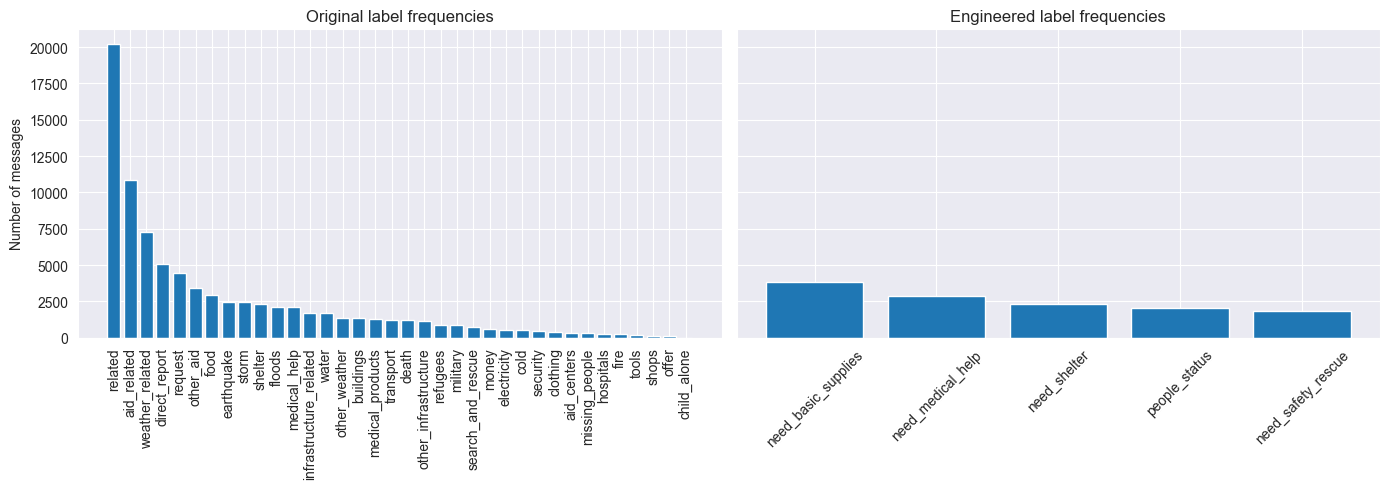

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt
from utilities import helper

orig_labels = helper.get_label_columns(df_raw)
new_labels = helper.get_label_columns(df)
raw_counts = df_raw[orig_labels].sum().sort_values(ascending=False)
new_counts = df[new_labels].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].set_title("Original label frequencies")
axes[0].bar(raw_counts.index, raw_counts.values)
axes[0].set_ylabel("Number of messages")
axes[0].tick_params(axis="x", rotation=90)

axes[1].set_title("Engineered label frequencies")
axes[1].bar(new_counts.index, new_counts.values)
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

The bar chart on the left shows the original label frequency. As we can see, the more broad labels such as *related, aid_related* and *weather_related* dominate over the more specific ones. Labels such as *tools, shops* and *offer* are one of the rarest categories. The visualisation also confirms that the *child_alone* label does not apply to any of the messages.

The right bar chart presents the frequency of the new labels. Each label has a specific fraction of messages, none of which goes exceeds 5 thousand messages. Compared to the original categories, the new target is smaller, more balanced and focused specifically on project idea.

#### Labels per message
In this step, I will check the number of labels per message, before and after feature engineering to understand the density of the label annotations:

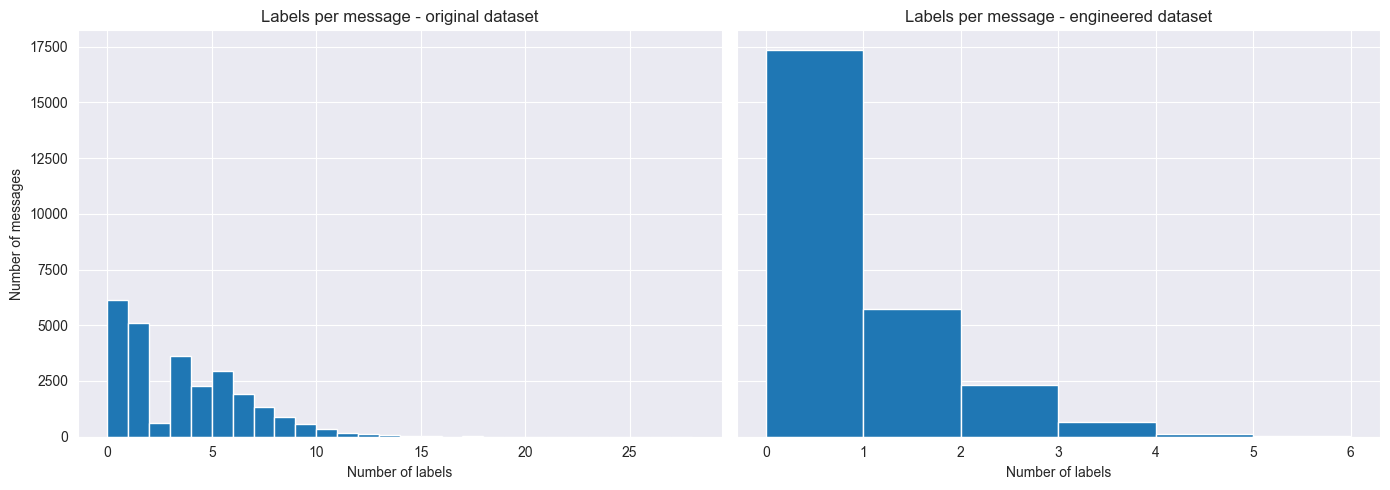

In [167]:
raw_label_counts = df_raw[orig_labels].sum(axis=1)
new_label_counts = df[new_labels].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].hist(raw_label_counts, bins=range(0, raw_label_counts.max()+2))
axes[0].set_title("Labels per message - original dataset")
axes[0].set_xlabel("Number of labels")
axes[0].set_ylabel("Number of messages")

axes[1].hist(new_label_counts, bins=range(0, new_label_counts.max()+2))
axes[1].set_title("Labels per message - engineered dataset")
axes[1].set_xlabel("Number of labels")
plt.tight_layout()
plt.show()

The bar charts show the amount of labels each message has. Both charts are strongly right-skewed which indicates that most messages have a smaller amount of labels. The results in the original dataset chart show that the most messages have between 0 and 5 labels, while a smaller fraction receives even more. The right diagram shows that most messages do not express any needs or people status - a lot of messages do not have any labels. Among the remaining messages, most have between 1 and 2 labels. This reflects the fact that the new labels are more selective and need-focused, which leads to a clear imbalance between not-annotated messages and messages with at least 1 or more labels.

#### Check missingness
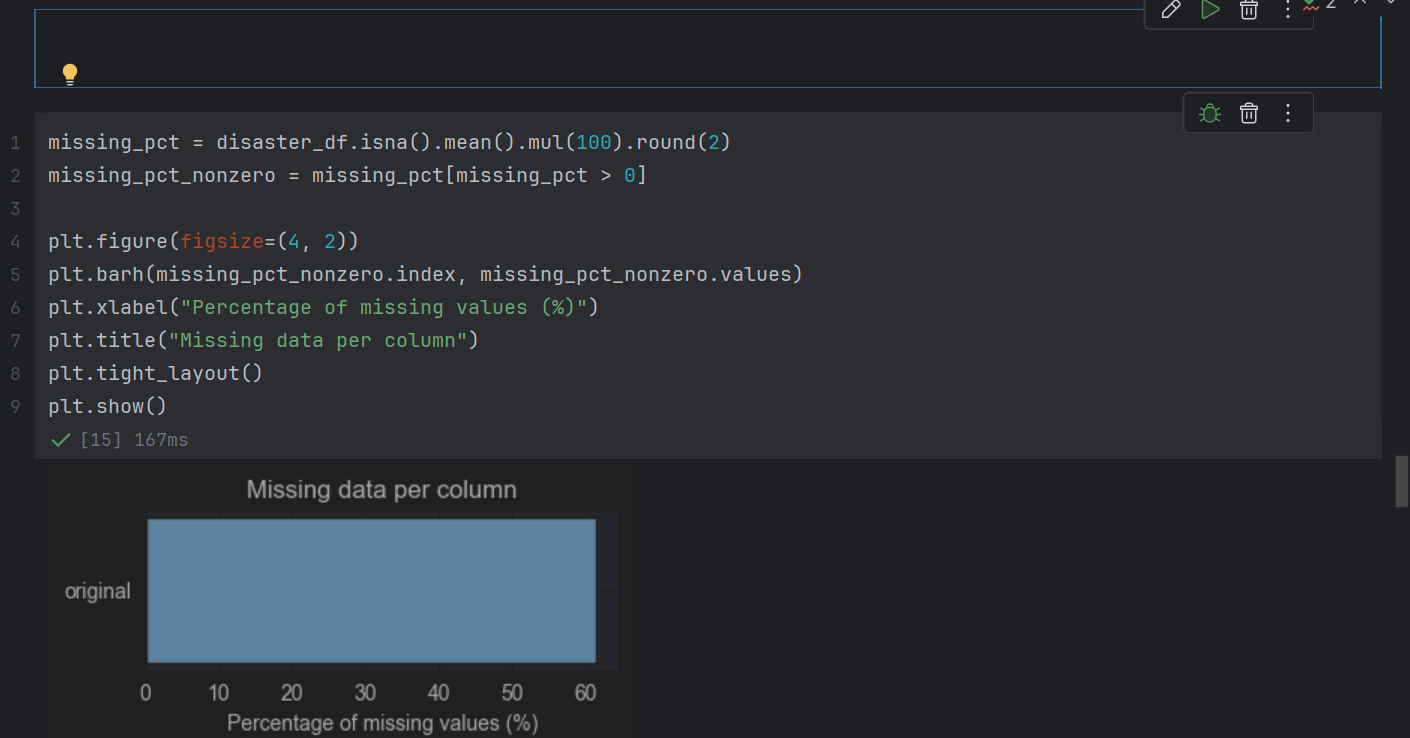

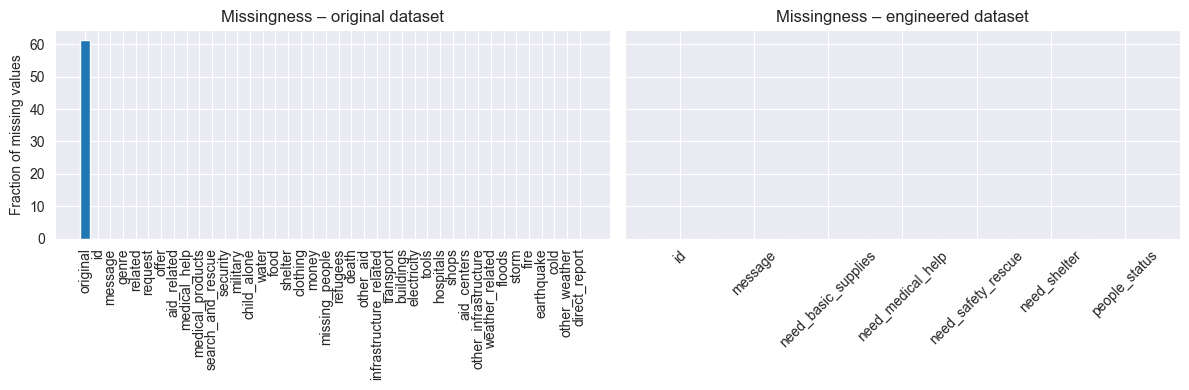

In [168]:
missing_raw = (df_raw.isna().mean()*100).sort_values(ascending=False)
missing_new = (df.isna().mean()*100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].bar(missing_raw.index, missing_raw.values)
axes[0].set_title("Missingness – original dataset")
axes[0].set_ylabel("Fraction of missing values")
axes[0].tick_params(axis="x", rotation=90)

axes[1].bar(missing_new.index, missing_new.values)
axes[1].set_title("Missingness – engineered dataset")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

The results above show that the only column, with detected missingness of more than 60%, is the *original* column the dataset before engineering, which was already expected. This column stores the original message before translating it to English, but if the message is originally written in English, the column stays empty. Since this project focuses only on the English version of the messages, this column was removed from the engineered dataset. The right graph confirms that after dropping the unnecessary columns no missingness remains in the data which will be used for modelling.

#### Check message length
In this step, I will inspect message length based on the amount of words detected in each text. The plots below will help me identify extremely short or long messages and guide my decision on whether I should remove those outliers:

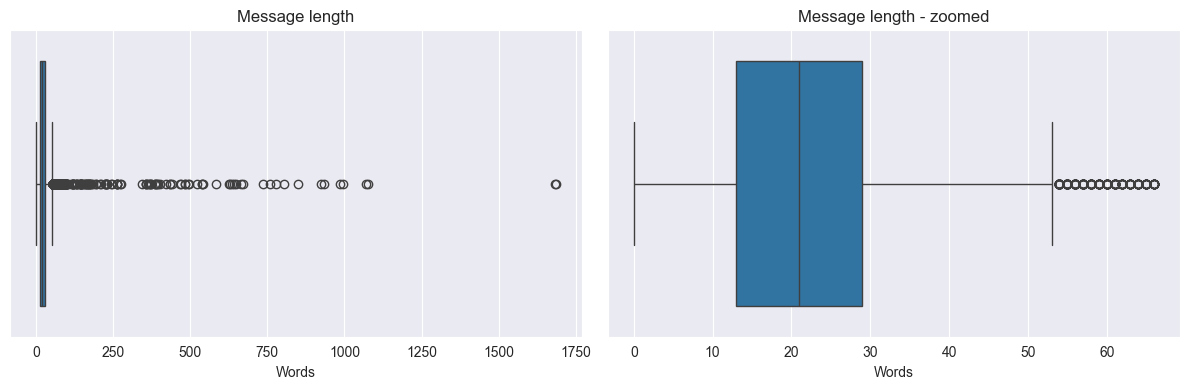

In [169]:
df["msg_len"] = df["message"].str.split().str.len()
p99 = df["msg_len"].quantile(0.99)
short_df = df[df["msg_len"] <= p99]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["msg_len"], ax=axes[0])
axes[0].set_title("Message length")
axes[0].set_xlabel("Words")

sns.boxplot(x=short_df["msg_len"], ax=axes[1])
axes[1].set_title("Message length - zoomed")
axes[1].set_xlabel("Words")
plt.tight_layout()
plt.show()

In [170]:
word_stats = df["msg_len"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])
word_stats

count    26180.000000
mean        23.857792
std         32.204283
min          0.000000
1%           5.000000
5%           7.000000
50%         21.000000
95%         45.000000
99%         66.000000
max       1686.000000
Name: msg_len, dtype: float64

This message-length analysis shows that most of the messages in the dataset are short - the average is 21 words, while 99% stay below 66 words. However, the boxplots clearly show that there are some extreme cases, such as completely empty messages (no words detected) and very long messages up to 1686 words. This clearly suggests that most messages in the dataset fall in a range of 5-66 words.

#### Detect the amount of extremely long and short messages
Do inspect extreme messages, I created two boolean masks - for those with at most 2 words and for those with at least 100 words. These cut-offs were based on the observed length range mentioned in the previous step, where most messages fall roughly between 5 and 60 words. Messages with at most 2 words are much smaller and could potentially not contain any valuable information, while messages with at least 100 words are way beyond the range limit and might be irrelevant for organizations like the Red Cross.

In [171]:
short_mask = df["msg_len"] <=5
long_mask  = df["msg_len"] >= 100
n_total = len(df)
n_short = short_mask.sum()
n_long  = long_mask.sum()

print(f"Extremely short: {n_short}")
print(f"Extremely long: {n_long}")

Extremely short: 371
Extremely long: 108


The results show that there are 112 extremely short and 108 extremely long messages. To gain a better understanding of whether those messages are worth keeping, I will visually examine some samples. The table below shows the 10 random samples of all short messages:

In [172]:
pd.set_option("display.max_colwidth", None)
df.loc[short_mask, ["id", "message"]].sample(10)

,id,message
10635,12234,warm cloths and non-perishable food
4881,5576,My child is seriously injured.
18485,21661,Refugees International therefore recommends that:
9703,10956,NOTES: It's already translate.
8265,9287,I@UU#UTGa UTUUUXU UU@UU@UUp U.
12035,13935,Another quick trip to Santiago..
9692,10942,What is the urgence information?
21511,25006,See http://www.iwpr.net/index.pl?local_caucasus/caucasus_panorama.html
6270,7150,"Hello, I search Jobs.Whenever"
2840,3277,We need information on protection.


From the table above, we can see that all of these extremely short messages are clearly non-informative. They do not represent real crisis communication and would only add noise. This is why, these samples will be removed:

In [173]:
df = df[~short_mask].copy()
print("Number of remaining messages:", len(df))

Number of remaining messages: 25809


Now, I will inspect 3 random samples from the extremely long detected messages:

In [189]:
pd.set_option("display.max_colwidth", None)
df.loc[long_mask, ["message"]].sample(3)

,message
22010,"It is very tragic that a medical technician in Quetta has been refusing vaccination for his children. * 4 dry ration distribution points have been selected for the beginning in the most vulnerable zones identified in the three targeted districts : Geladid, Dalat, Dawahale and Jilahle. - The United Nations should stengthen its support for the Burma Country team by hiring a Senior Humanitarian Advisor to work with the RC/HC and ensure that teams in Bangkok and New York are providing adequate guidance and support. In Unit 2 water transfer from the condenser to the condensate storage tank was completed on 9th April.Sri Lanka's minister of health laid the foundation stone for a new three-storey building complex at Polonnaruwa General Hospital. The Red Cross Red CrescentMovement has been involved in two of them, a pooled"" distribution of supplies by small boat along the coast and navigable rivers, and direct supply to displaced people in Popondetta and villages that can still be reached by road."
12603,Ready for Sandy #stormofthecentury #survivalkit @cacapoopoopeepee shire http://t.co/4QOeKeuo@StormSandy_: Jackson's full of dope heads that probably don't even realize there's a storm.‚àö√Ü hahhahahaahhah_Blow bitch blow. (Hurricane Sandy) that is. Manhattan and Wards Islands across the East River view from Astoria Queens. http://t.co/wlEI77EmFirst tree casualty in my neighborhood from Sandy in New Haven. http://t.co/aKvpjZ5t@antocurcio: No power already r u kidding me my house was 2 and 0 had power through irene and the snow storm #wtf #nopower #fucksandy‚àö√Ü nooo@MsDtermined the lower east side is in an A zone. Besides I have fam in FL I witness real hurricanes. This isn't even a tropical storm
18051,"The gunmen arrived around 7:30 pm (1830 GMT), firing guns and shouting 'Allahu Akbar!'. Fartun notes, ""I am grateful to International Medical Corps that I received the personal hygiene items for free which will enable me and my family to have good personal hygiene."". Now the few water tanks used to collect rainwater have been destroyed. The cross-border movement of the human remains of deceased suspect, probable or confirmed EVD cases should be prohibited unless specifically authorized on a case-by-case basis by relevant national authorities of both the exporting and receiving country. Flooding is an annual occurrence in Thailand, most of which lies in the drainage basin of the Chao Phraya River flowing from the confluence of the Ping and Nan rivers in the north. With the Ministry of Rural Rehabilitation and Development as the major counterpart, the WES programme aims, to construct or rehabilitate handpumps, dug wells, boreholes, latrines, piped water systems, and sanitation systems. International aid agencies on the ground hope this will go towards constructing wells and latrines to deal with the underlying causes of the outbreak. Across the board, households are spending a higher proportion of their limited incomes on their food needs; they are consuming smaller quantities, less frequently; and they are eating cheaper and in many (but by no means all) cases, less nutritious foods. The assets and logistical capability provided by military forces after the tsunami were essential in ensuring humanitarian supplies were delivered swiftly. Other specialists are working to clean up polluted wells in the Meulaboh region. Sukamto said the haze could lead to lung infections and pneumonia that sometimes can become fatal. The Southern part of Madagascar is subject to cyclical drought. As well, just this morning, Pepsico hosted a breakfast symposium on undernutrition with leading experts from the Gates Foundation, Save the Children, GAIN and Valid International, all sitting along side Pepsi reseachers and discussing new approaches to address global child undernutrition. His appeal to donors making generous pledges was for them to earmark the monies, such as to the regional component, or to Indonesia, Somalia and so forth. In a

After inspecting the extremely long messages, I decided to keep them as they represent detailed crisis-related reports rather than noisy, non-informative long texts.

#### Check dataset balance
After removing the extremely short, non-informative messages, I will check the distribution between messages with and without labels to understand the final dataset imbalance and decide how to handle it properly:

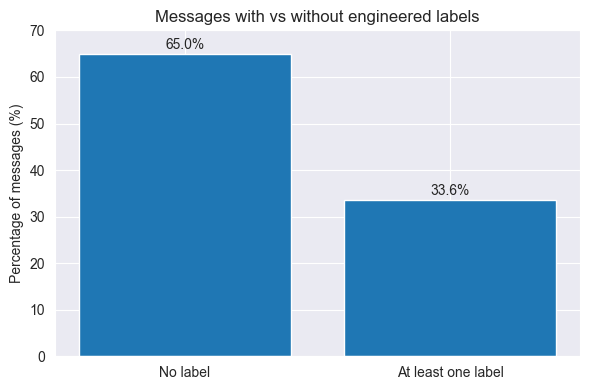

In [191]:
has_any_new = (df[new_labels].sum(axis=1) > 0)
counts_new = has_any_new.value_counts().sort_index()
labels = ["No label", "At least one label"]
values_pct = [counts_new[False] / n_total * 100,counts_new[True] / n_total * 100]

plt.figure(figsize=(6, 4))
plt.bar(labels, values_pct)
plt.ylabel("Percentage of messages (%)")
plt.title("Messages with vs without engineered labels")
for i, v in enumerate(values_pct):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.ylim(0, max(values_pct) + 5)
plt.tight_layout()
plt.show()

The visualisation above compares the percentage of messages with and without labels. As we can see, more than 60% do not have any need-related labels, while slightly more than 30% has at least 1. This was already expected because of the already existing imbalance in the original dataset and the fact that the new engineered labels are more specific and only capture needs and people status. However, the ratio between no-labels vs labels (2:1) shows moderate imbalance, which will be handled at model level - no undersampling will be applied.

## Extract small inference set
Before creating the train/val/test split, I will extract a small subset for inference testing and demonstrating the behaviour of the final model on completely unseen messages. In the code below, I split the dataset into 2 groups - with at least one positive label and without any labels to ensure diversity. Then, I randomly select 10 samples without any labels. Next, for each label in the dataset, I select all messages where this label is positive and randomly get 10 samples. Finally, I remove the selected samples from the main dataset and save them in the `final` folder:

In [195]:
df_with = df[has_any_new].copy()
df_without = df[~has_any_new].copy()
inf_without =  df_without.sample(n=min(10, len(df_without)), random_state=42)
infer_with_parts = []
for label in new_labels:
    candidates = df_with[df_with[label] == 1]
    n = min(10, len(candidates))
    if n > 0:
        infer_with_parts.append(candidates.sample(n=n, random_state=42))

infer_pos = pd.concat(infer_with_parts)
df_inference = pd.concat([inf_without, infer_pos])
df_model = df.drop(index=df_inference.index).reset_index(drop=True)
df_inference.to_csv("../data/final/disaster_inference.csv", index=False)
df_model.to_csv("../data/final/disaster_dataset.csv", index=False)

print("Inference set:", df_inference.shape)
print("Modelling set:", df_model.shape)

Inference set: (60, 7)
Modelling set: (25749, 7)


## Feature selection
In this step, I select the *message* column as input feature for my models and the all remaining label columns as multi-label target. This step ensures that only relevant information is used for training.

In [196]:
feature = df_model["message"]
label_cols = helper.get_label_columns(df_model)

x = feature.copy()
y = df_model[label_cols].copy()

## Splitting into train/val/test sets
In this step, I split my data into three subsets - train (70%), validation (15%) and test (15%). First, I split the data into train/temporary subsets. Then, I split the temporary subset evenly into validation and test sets. I chose this separation as it will allow me to train and tune all models on the train/validation sets, while keeping the testing one completely unseen. I use stratification based on whether the message has at least one positive label or not to ensure similar proportions in each set. Lastly, I print the number of rows in each set to verify that the split matches the intended ratio:

In [197]:
from sklearn.model_selection import train_test_split

has_any = (y.sum(axis=1) > 0).astype(int)
X_train, X_temp, y_train, y_temp, has_any_train, has_any_temp = train_test_split(x,y,has_any,test_size=0.30,random_state=42, stratify=has_any)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.50,random_state=42, stratify=has_any_temp)

for name, arr in [("X_train:", X_train),("X_val:",   X_val),("X_test:",  X_test)]:
    print(name, arr.shape[0])

X_train: 18024
X_val: 3862
X_test: 3863


#### Save train/val/test sets
This step is very important, as it ensures the consistency and reproducibility across all models. The subsets are saved in separate files so that each model can use the exactly same input data during training, validation and evaluation.

In [198]:
X_train.to_csv("../data/split_data/X_train.csv", index=False)
X_val.to_csv("../data/split_data/X_val.csv", index=False)
X_test.to_csv("../data/split_data/X_test.csv", index=False)

y_train.to_csv("../data/split_data/y_train.csv", index=False)
y_val.to_csv("../data/split_data/y_val.csv", index=False)
y_test.to_csv("../data/split_data/y_test.csv", index=False)

## Text normalization
#### Converting to lowercase
The first step in the text normalization phase is to lowercase all messages. This is an important step that ensures all words with different capitalization patterns are treated as the same token. It also makes the TF-IDF representation more compact and consistent.

**Example:**
Without lowercasing, the 3 different versions of "water" would be treated as different tokens.
*Before lowercasing:* "water", "Water", "WATER"
*After lowercasing:* "water"

In [89]:
messages = X_train.copy()
lowered_messages = messages.str.lower()

df = pd.DataFrame({"original": messages, "lowercased": lowered_messages})
df.head()

,original,lowercased
23753,"The challenge for governments, with FAO assistance, is to review measures to be taken in the veterinary realm, despite the fact that ""there is currently no evidence to suggest that the novel human-to-human transmitted H1N1 influenza virus is circulating in pigs in Mexico or anywhere else in the world, reasserted FAO Chief Veterinary Officer of FAO, Mr. Joseph Domenech.","the challenge for governments, with fao assistance, is to review measures to be taken in the veterinary realm, despite the fact that ""there is currently no evidence to suggest that the novel human-to-human transmitted h1n1 influenza virus is circulating in pigs in mexico or anywhere else in the world, reasserted fao chief veterinary officer of fao, mr. joseph domenech."
13252,"They have to endure scorching heat in the day but they are drenched when it's rains, he said.","they have to endure scorching heat in the day but they are drenched when it's rains, he said."
3803,Why not do something for the people- Please check on some in need in the yard of Fanmpac Co. on National rte #1 Bwin courtyard next to Unibank.,why not do something for the people- please check on some in need in the yard of fanmpac co. on national rte #1 bwin courtyard next to unibank.
14284,"HANOI, Apr 5, 2002 (Xinhua via COMTEX) -- Fires that have been raging in Vietnam's U Minh Thuong National Park for the last 10 days destroyed more than 4,000 hectares (ha) of the country's virgin cajeput forest, the Vietnam News reported Friday.","hanoi, apr 5, 2002 (xinhua via comtex) -- fires that have been raging in vietnam's u minh thuong national park for the last 10 days destroyed more than 4,000 hectares (ha) of the country's virgin cajeput forest, the vietnam news reported friday."
5195,"Delmas 60, Argentina at the entrance. Thank you for the service. May god bless You All.","delmas 60, argentina at the entrance. thank you for the service. may god bless you all."


#### Replacing URLs and email addresses
Some messages in the dataset, contain URLs and email addresses, for references to news articles or contact details. Usually, they are not relevant for the model and can be replaced with fixed placeholder tokens that will allow the model understand there is an email or link. This will also help reducing the noise and the vocabulary size:

In [11]:
mask_urls_emails = df["lowercased"].str.contains(r"http|www\.|@\w+\.\w+", regex=True, na=False)
examples = df["lowercased"].loc[mask_urls_emails].copy()
examples_norm = examples.str.replace(r"http\S+|www\.\S+", " URLTOK ", regex=True)
examples_norm = examples_norm.str.replace(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " EMAILTOK ", regex=True)
df_examples = pd.DataFrame({"original": examples, "after_url_email_replacement": examples_norm})
df_examples.head()

,original,after_url_email_replacement
14,were just able to post on santiago times (heavy traffic crashed out site earlier): http://bit.ly/apz2eh,were just able to post on santiago times (heavy traffic crashed out site earlier): URLTOK
32,canadarights.com magazine pics haiti country?||haiti in world map|haiti earthquake .. despite having common cul.. http bit.ly 82pxcf,canadarights.com magazine pics haiti country?||haiti in world map|haiti earthquake .. despite having common cul.. http bit.ly 82pxcf
50,jenga and wine by fake candle light. f u sandy! @ksep inn http://t.co/cw7vqegzdrizzle and light winds on w. 57th. nothing yet. #sandy,jenga and wine by fake candle light. f u sandy! @ksep inn URLTOK and light winds on w. 57th. nothing yet. #sandy
53,largest earthquake in more than 200 years strikes haiti http wp.me sn9bu 8296 u00ab baptistplanet http ff.im eevbo,largest earthquake in more than 200 years strikes haiti http wp.me sn9bu 8296 u00ab baptistplanet http ff.im eevbo
55,"ready for #hurricanesandy. be safe everyone!! #newyork #nyc #queens #hurricane #instamo @fresh meadows, ny http://t.co/9pboboyh","ready for #hurricanesandy. be safe everyone!! #newyork #nyc #queens #hurricane #instamo @fresh meadows, ny URLTOK"


#### Handling hashtags and user mentions
Some messages come from social media, which is why they might contain hashtags and user mentions, as in some of the samples above. In this project, they are considered not informative and will be handled similarly to the URLs and emails:

In [14]:
examples_norm = df_examples["after_url_email_replacement"].str.replace(r"#(\w+)", " HASHTAGTOK ", regex=True)
examples_norm = examples_norm.str.replace(r"@\w+", " MENTIONTOK ", regex=True)
df_ex = pd.DataFrame({"original": df_examples["after_url_email_replacement"].values,"after_hashtag_mention_handling": examples_norm.values})
df_ex.head()

,original,after_hashtag_mention_handling
0,were just able to post on santiago times (heavy traffic crashed out site earlier): URLTOK,were just able to post on santiago times (heavy traffic crashed out site earlier): URLTOK
1,canadarights.com magazine pics haiti country?||haiti in world map|haiti earthquake .. despite having common cul.. http bit.ly 82pxcf,canadarights.com magazine pics haiti country?||haiti in world map|haiti earthquake .. despite having common cul.. http bit.ly 82pxcf
2,jenga and wine by fake candle light. f u sandy! @ksep inn URLTOK and light winds on w. 57th. nothing yet. #sandy,jenga and wine by fake candle light. f u sandy! MENTIONTOK inn URLTOK and light winds on w. 57th. nothing yet. HASHTAGTOK
3,largest earthquake in more than 200 years strikes haiti http wp.me sn9bu 8296 u00ab baptistplanet http ff.im eevbo,largest earthquake in more than 200 years strikes haiti http wp.me sn9bu 8296 u00ab baptistplanet http ff.im eevbo
4,"ready for #hurricanesandy. be safe everyone!! #newyork #nyc #queens #hurricane #instamo @fresh meadows, ny URLTOK","ready for HASHTAGTOK . be safe everyone!! HASHTAGTOK HASHTAGTOK HASHTAGTOK HASHTAGTOK HASHTAGTOK MENTIONTOK meadows, ny URLTOK"


#### Normalizing numbers
Many crisis messages contain numbers, specifying things like number of injured people or number of resources needed. For this project the exact number is less important and keeping each number as a separate token would increase the size of the vocabulary. This is why, I will replace each number with a "num" token:

In [15]:
examples_num =  df_ex["after_hashtag_mention_handling"].copy()
examples_num_norm = examples_num.str.replace(r"\d+", " NUMTOK ", regex=True)
df_num = pd.DataFrame({"original": examples_num.values,"after_number_norm": examples_num_norm.values})
df_num.head()

,original,after_number_norm
0,were just able to post on santiago times (heavy traffic crashed out site earlier): URLTOK,were just able to post on santiago times (heavy traffic crashed out site earlier): URLTOK
1,canadarights.com magazine pics haiti country?||haiti in world map|haiti earthquake .. despite having common cul.. http bit.ly 82pxcf,canadarights.com magazine pics haiti country?||haiti in world map|haiti earthquake .. despite having common cul.. http bit.ly NUMTOK pxcf
2,jenga and wine by fake candle light. f u sandy! MENTIONTOK inn URLTOK and light winds on w. 57th. nothing yet. HASHTAGTOK,jenga and wine by fake candle light. f u sandy! MENTIONTOK inn URLTOK and light winds on w. NUMTOK th. nothing yet. HASHTAGTOK
3,largest earthquake in more than 200 years strikes haiti http wp.me sn9bu 8296 u00ab baptistplanet http ff.im eevbo,largest earthquake in more than NUMTOK years strikes haiti http wp.me sn NUMTOK bu NUMTOK u NUMTOK ab baptistplanet http ff.im eevbo
4,"ready for HASHTAGTOK . be safe everyone!! HASHTAGTOK HASHTAGTOK HASHTAGTOK HASHTAGTOK HASHTAGTOK MENTIONTOK meadows, ny URLTOK","ready for HASHTAGTOK . be safe everyone!! HASHTAGTOK HASHTAGTOK HASHTAGTOK HASHTAGTOK HASHTAGTOK MENTIONTOK meadows, ny URLTOK"


#### Lemmatization
As a last text normalization step, I will apply lemmatization. This technique is used to reduce words to their base or dictionary form to ensure words with similar meanings are treated the same. In this project, I decided to use "spaCy", as it gives accurate part-of-speech-aware lemmas (can distinguish verbs from adjectives, etc.) and works fast.
<p style="text-align: center;">
  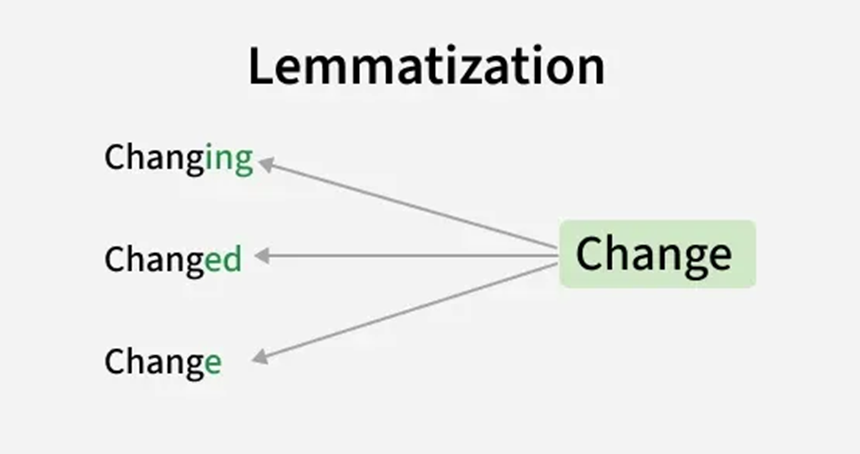
</p>
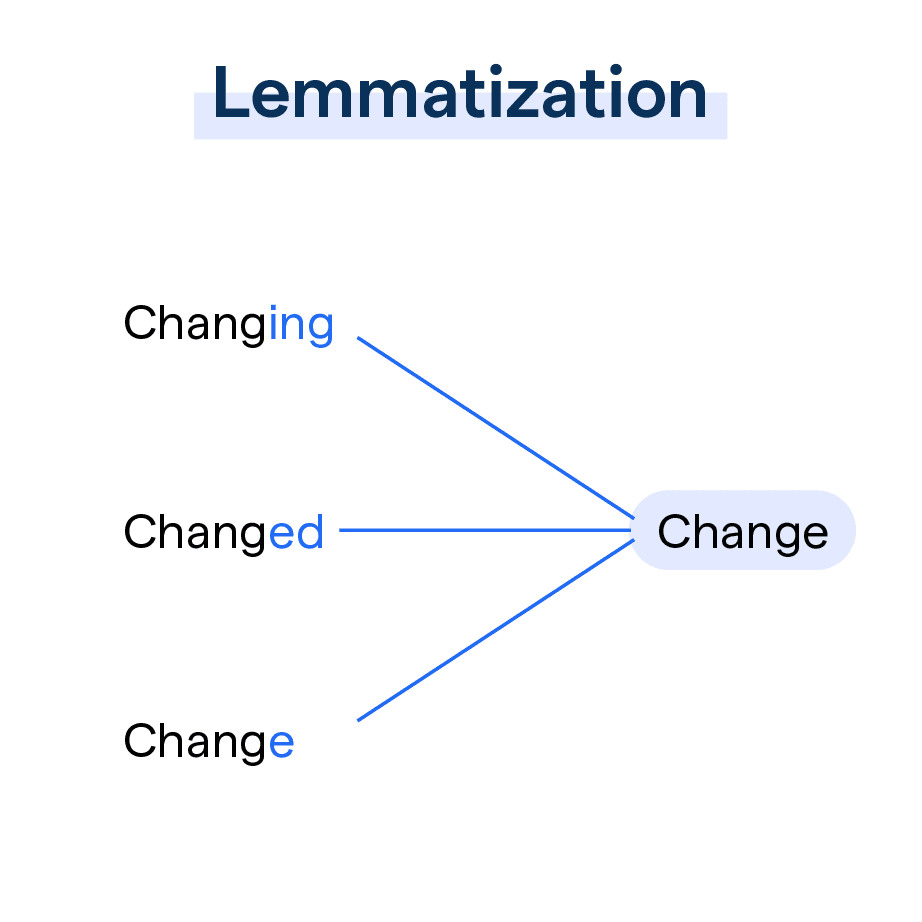
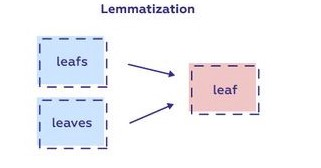

In [18]:
import spacy

special = {"URLTOK", "EMAILTOK", "NUMTOK", "MENTIONTOK", "HASHTAGTOK"}
def lemmatize_text(text):
    doc = nlp(text)
    lemmas = []
    for token in doc:
        if token.is_space:
            continue

        t = token.text
        if t in special:
            lemmas.append(t.lower())
        else:
            lemmas.append(token.lemma_.lower())

    return " ".join(lemmas)

nlp = spacy.load("en_core_web_sm")
ex_lem = df_num["after_number_norm"].copy()
examples_lem_norm = ex_lem.apply(lemmatize_text)
df_lem = pd.DataFrame({"original": ex_lem.values,"lemmatization": examples_lem_norm.values})
df_lem.head()

,original,lemmatization
0,were just able to post on santiago times (heavy traffic crashed out site earlier): URLTOK,be just able to post on santiago time ( heavy traffic crash out site early ): urltok
1,canadarights.com magazine pics haiti country?||haiti in world map|haiti earthquake .. despite having common cul.. http bit.ly NUMTOK pxcf,canadarights.com magazine pic haiti country?||haiti in world map|haiti earthquake .. despite have common cul .. http bit.ly numtok pxcf
2,jenga and wine by fake candle light. f u sandy! MENTIONTOK inn URLTOK and light winds on w. NUMTOK th. nothing yet. HASHTAGTOK,jenga and wine by fake candle light . f u sandy ! mentiontok inn urltok and light wind on w. numtok th . nothing yet . hashtagtok
3,largest earthquake in more than NUMTOK years strikes haiti http wp.me sn NUMTOK bu NUMTOK u NUMTOK ab baptistplanet http ff.im eevbo,large earthquake in more than numtok year strike haiti http wp.me sn numtok bu numtok u numtok ab baptistplanet http ff.im eevbo
4,"ready for HASHTAGTOK . be safe everyone!! HASHTAGTOK HASHTAGTOK HASHTAGTOK HASHTAGTOK HASHTAGTOK MENTIONTOK meadows, ny URLTOK","ready for hashtagtok . be safe everyone ! ! hashtagtok hashtagtok hashtagtok hashtagtok hashtagtok mentiontok meadow , ny urltok"


To lemmatize the messages in the dataset, I created the `lemmatize_text` function, which uses the loaded English spaCy model to extract lemmatized tokens from the passed texts, while skipping spaces, so they are not counted as separate words. Then, it checks for special tokens by comparing each one to the "special" list, which is done to prevent lemmatizing them. For all normal words, it takes their base forms and adds them to the list. Lastly, all lemmas are joined with spaces and return as a single string.

## Term Frequency - Inverse Document Frequency
TF-IDF is a statistical method used in natural language preprocessing to measure how important a word is.
 - *Term Frequency* - measures how important a word is in a message; the more the word appear, the greater importance it has
 - *Inverse Document Frequency* - measures how rare a word is across all given messages

The final weight is based on the terms above -  the more frequently a word appears in a message and the least frequently it appears across the whole dataset, the higher its final TF-IDF will be. In the example below, I use the small dataset with lemmatized samples to show how TF-IDF works. First, I fit the vectorizer on the small dataset, so it can learn which tokens appears often and assess how rare it is. Then, I select one message and extract its TF-IDF vector results. I filter the samples with non-zero weights. Lastly, I sort the top 10 weights, starting from the most important one.

In [144]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

texts = df_lem["lemmatization"].tolist()
vectorizer = TfidfVectorizer(ngram_range=(1, 2),max_features=10000,stop_words="english",min_df=3)
X_tfidf = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

tfidf_row    = X_tfidf[100].toarray()[0]
nonzero_idx = np.where(tfidf_row > 0)[0]
token_weights = [(feature_names[i], tfidf_row[i]) for i in nonzero_idx]
token_weights_sorted = sorted(token_weights, key=lambda x: x[1], reverse=True)
top10 = token_weights_sorted[:10]

df_tfidf_example = pd.DataFrame(top10, columns=["token", "tfidf_weight"])
df_tfidf_example

,token,tfidf_weight
0,help,0.285351
1,donation num,0.259758
2,num help,0.259758
3,want help,0.259758
4,haiti info,0.250537
5,victim haiti,0.250537
6,help earthquake,0.236632
7,help http,0.231114
8,info,0.231114
9,unicef,0.226247


From the table above, we can see that the TF-IDF assigns words like "help", "donation num" and "num help" as top 3 most important words for this message. The results suggest that the message is dominated by requests for help and donations, specifically related to the victims of the haiti earthquake.